In [42]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
from heatextremes.metrics import coverage, mean_in_time_batches, probability_of_exceedance_brier_score
import heatextremes as he 
from dask.diagnostics import ProgressBar 
from dask.distributed import Client
from pathlib import Path 
import pandas as pd 

import warnings
from zarr.errors import ZarrUserWarning



In [43]:
ds = xr.open_zarr("/home/kylehall/precipitation_verification/precipitation_case_metrics.zarr/", chunks={}, consolidated=True)

In [44]:
with ProgressBar():
    toplot = ds['coverage_p90_total_precipitation'].mean('time').compute()

[########################################] | 100% Completed | 32.93 s


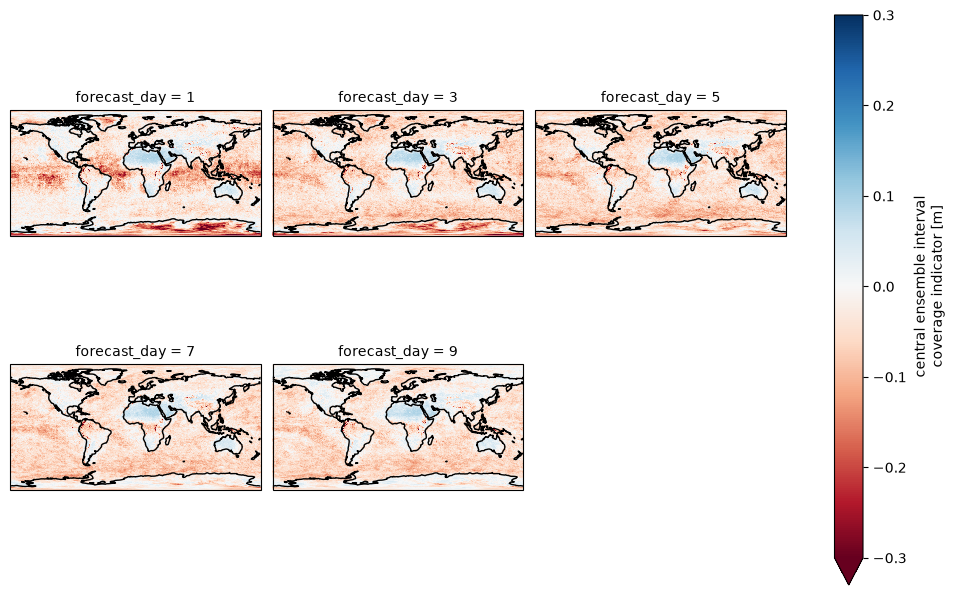

In [48]:

region = (toplot - 0.9) #.sel(
   # latitude=slice(42, 12),
   # longitude=slice(-18, 65),
#)

pl = region.plot(
    col="forecast_day",
    col_wrap=3,
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(),
    cmap="RdBu",
    vmin=-0.3, vmax=0.3
)

for ax in pl.axs.flat:
    #ax.set_extent(
    #    [-18, 65, 12, 42],
    #    crs=ccrs.PlateCarree(),
    #)
    ax.coastlines()



In [49]:

era5 = xr.open_dataset('/home/kylehall/precipitation_verification/era5_daily_precipitation_matched.zarr', chunks={}, consolidated=True)
aifs = xr.open_dataset('/home/kylehall/precipitation_verification/aifs_daily_precipitation.zarr', chunks={}, consolidated=True)

In [50]:
with ProgressBar():
    rmse = np.sqrt( ((era5 - aifs.mean('number'))**2).mean('time')).compute()

[########################################] | 100% Completed | 101.80 ms
[########################################] | 100% Completed | 103.68 ms
[########################################] | 100% Completed | 101.76 ms
[########################################] | 100% Completed | 102.71 ms
[########################################] | 100% Completed | 20m 1ss


In [51]:
rmse

<xarray.Dataset> Size: 21MB
Dimensions:                     (forecast_day: 5, latitude: 721, longitude: 1440)
Coordinates:
  * forecast_day                (forecast_day) int64 40B 1 3 5 7 9
    forecast_lead_end           (forecast_day) timedelta64[ns] 40B 1 days ......
    forecast_lead_start         (forecast_day) timedelta64[ns] 40B 0 days ......
    prediction_timedelta_daily  (forecast_day) timedelta64[ns] 40B 1 days ......
  * latitude                    (latitude) float64 6kB 90.0 89.75 ... -90.0
  * longitude                   (longitude) float64 12kB -180.0 -179.8 ... 179.8
Data variables:
    total_precipitation         (forecast_day, latitude, longitude) float32 21MB ...
Attributes:
    model_store:          /net/monsoon/kylehall/heat_extremes/precipitation_v...
    forecast_year_start:  2022
    forecast_year_end:    2025

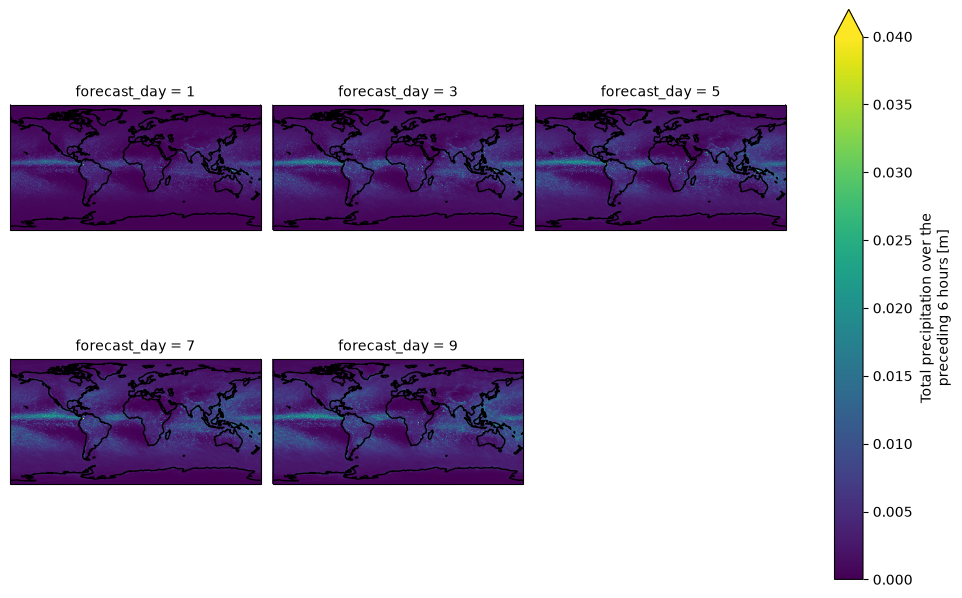

In [53]:

pl = rmse['total_precipitation'].plot(
    col="forecast_day",
    col_wrap=3,
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=0, vmax = 0.04
)

for ax in pl.axs.flat:
    ax.coastlines()
